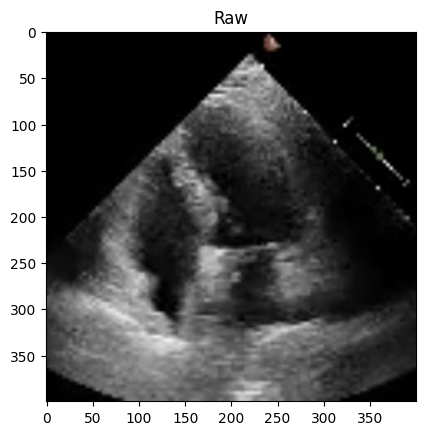

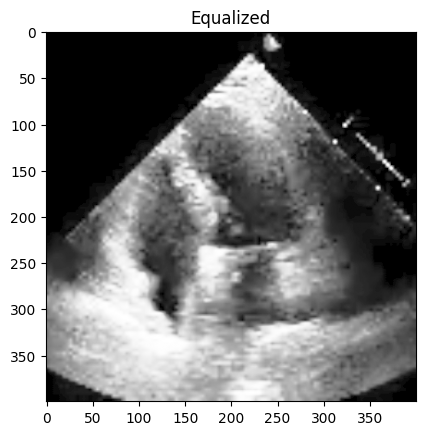

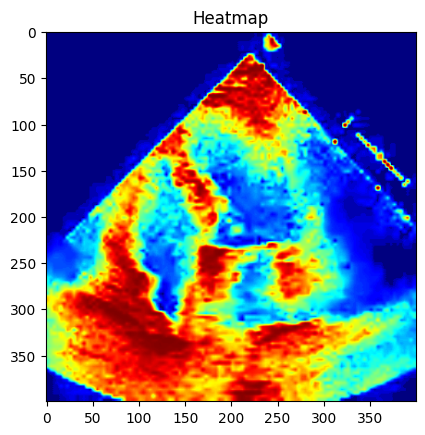

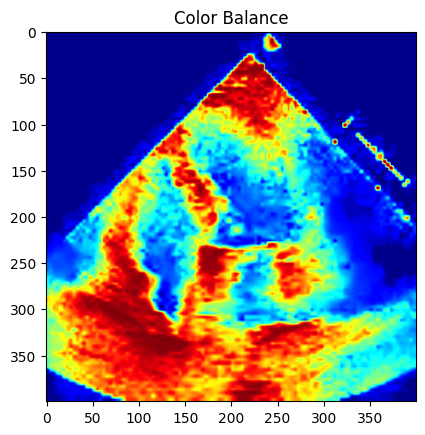

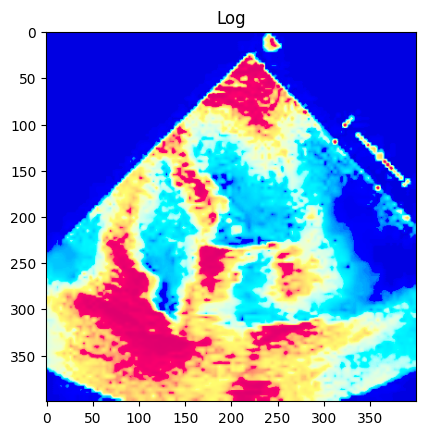

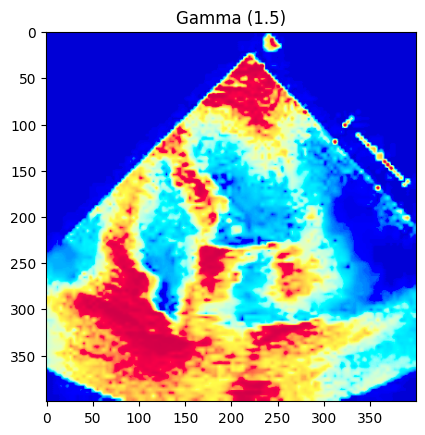

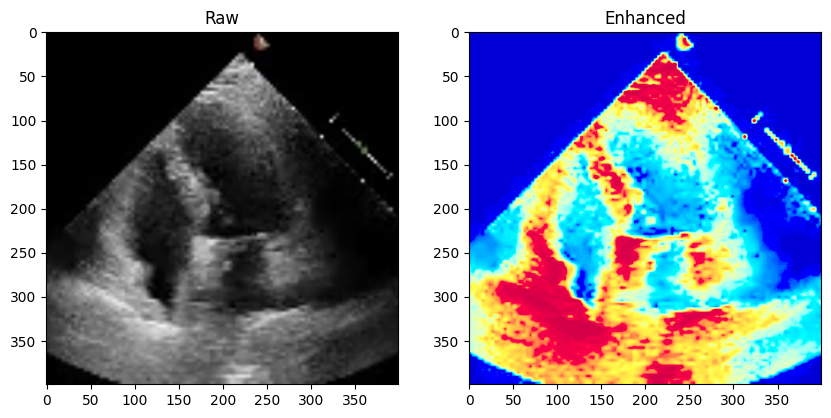

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = r'D:\Danias Code\CV\LAB 02\task3_echo_analysis\EchoNet-Dynamic\Videos\0X1A0A263B22CCD966.mp4'

cap = cv2.VideoCapture(path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, frame = cap.read()
cap.release()

frame = cv2.resize(frame, (400, 400))
plt.figure()
plt.imshow(frame[:, :, ::-1])
plt.title('Raw')
plt.show()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
eq = cv2.equalizeHist(gray)
plt.figure()
plt.imshow(eq, cmap='gray')
plt.title('Equalized')
plt.show()

heat = cv2.applyColorMap(eq, cv2.COLORMAP_JET)
plt.figure()
plt.imshow(heat[:, :, ::-1])
plt.title('Heatmap')
plt.show()

b, g, r = cv2.split(heat)
balanced = cv2.merge([cv2.add(b, 10), g, r])
plt.figure()
plt.imshow(balanced[:, :, ::-1])
plt.title('Color Balance')
plt.show()

log_f = 255 / np.log(256) * np.log(1 + balanced.astype(np.float32))
plt.figure()
plt.imshow(np.uint8(log_f)[:, :, ::-1])
plt.title('Log')
plt.show()

gamma_img = np.uint8(255 * (log_f / 255) ** 1.5)
plt.figure()
plt.imshow(gamma_img[:, :, ::-1])
plt.title('Gamma (1.5)')
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(frame[:, :, ::-1])
plt.title('Raw')
plt.subplot(1, 2, 2)
plt.imshow(gamma_img[:, :, ::-1])
plt.title('Enhanced')
plt.show()